## Step 01: Setup Environment

In [5]:
#check the python version and env and the pytorch version
import sys
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)


Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.5.1


## Step 02: Exploratory Data Analysis

In [12]:
#load the tex file and print the first 100 characters

print("Loading data...")
print("====================================================================")
print("Train data:")
print("====================================================================")
with open("./data/train.txt", "r") as f:
    data = f.read()
    print(data[:100])


print("====================================================================")
print("Validation data:")
print("====================================================================")
with open("./data/val.txt", "r") as f:
    data = f.read()
    print(data[:100])

print("====================================================================")
print("Test data:")
print("====================================================================")
with open("./data/test.txt", "r") as f:
    data = f.read()
    print(data[:100])

Loading data...
Train data:
Selegiline	O
-	O
induced	O
postural	B-Disease
hypotension	I-Disease
in	O
Parkinson	B-Disease
'	I-Dis
Validation data:
22	O
-	O
oxacalcitriol	O
suppresses	O
secondary	B-Disease
hyperparathyroidism	I-Disease
without	O
in
Test data:
Torsade	B-Disease
de	I-Disease
pointes	I-Disease
ventricular	B-Disease
tachycardia	I-Disease
during	


In [13]:
import os
import json

def parse_ner_file(file_path):
  
    sentences = []
    current_words = []
    current_labels = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            
            if not line:
                if current_words:
                    sentences.append({
                        "words": current_words,
                        "labels": current_labels
                    })
                    current_words = []
                    current_labels = []
                continue
            
        
            parts = line.split()
            if len(parts) >= 2:
                word = parts[0]
                label = parts[-1] 
                current_words.append(word)
                current_labels.append(label)
                
        
        if current_words:
            sentences.append({
                "words": current_words,
                "labels": current_labels
            })
            
    return sentences


In [ ]:
# --- Main Execution ---
data_dir = "./data"
output_dir = "./processed_base_data"
os.makedirs(output_dir, exist_ok=True)

files_to_process = ["train.txt", "val.txt", "test.txt"]

for file_name in files_to_process:
    input_path = os.path.join(data_dir, file_name)
    
    if os.path.exists(input_path):
        print(f"Processing {file_name}...")
        parsed_data = parse_ner_file(input_path)
        
        output_name = file_name.replace(".txt", ".json")
        output_path = os.path.join(output_dir, output_name)
        
        with open(output_path, "w", encoding="utf-8") as out_f:
            json.dump(parsed_data, out_f, indent=4)
            
        print(f"Successfully saved {len(parsed_data)} sentences to {output_path}")
    else:
        print(f"Error: {input_path} !")

print("====================================================================")
print("Base Data Preparation Done!")

Processing train.txt...
Successfully saved 4560 sentences to ./processed_base_data\train.json
Processing val.txt...
Successfully saved 4581 sentences to ./processed_base_data\val.json
Processing test.txt...
Successfully saved 4797 sentences to ./processed_base_data\test.json
Base Data Preparation Done!


In [17]:
with open("./processed_base_data/train.json", "r") as f:
    train_dataset = json.load(f)

print("First Sentence Words:", train_dataset[0]["words"])
print("First Sentence Labels:", train_dataset[0]["labels"])

First Sentence Words: ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']
First Sentence Labels: ['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [18]:
import json
import os

# Define the file paths for verification
data_files = {
    "Train Data": "./processed_base_data/train.json",
    "Validation Data": "./processed_base_data/val.json",
    "Test Data": "./processed_base_data/test.json"
}

print("Starting structural validation for dataset splits...")
print("====================================================================")

all_splits_valid = True

for split_name, file_path in data_files.items():
    if not os.path.exists(file_path):
        print(f"Warning: {split_name} file not found at {file_path}. Skipping...")
        continue
        
    print(f"Verifying {split_name}...")
    
    # Load the processed JSON data
    with open(file_path, "r", encoding="utf-8") as f:
        dataset = json.load(f)
        
    mismatched_sentences_count = 0
    total_sentences = len(dataset)
    
    # Loop through each sentence to check lengths
    for index, sample in enumerate(dataset):
        word_length = len(sample["words"])
        label_length = len(sample["labels"])
        
        # Check if the length of words matches the length of labels
        if word_length != label_length:
            print(f"  [Error] Mismatch found at sentence index {index}!")
            print(f"  Words ({word_length}): {sample['words']}")
            print(f"  Labels ({label_length}): {sample['labels']}")
            print("-" * 50)
            mismatched_sentences_count += 1
            all_splits_valid = False

    # Print summary statistics for the current split
    if mismatched_sentences_count == 0:
        print(f"  [Success] All {total_sentences} sentences are structurally sound.")
        print(f"  --> Word count and Tag count match perfectly for all sequences.")
    else:
        print(f"  [Failure] Found {mismatched_sentences_count} mismatched sequences out of {total_sentences}.")
        
    print("====================================================================")

# Final confirmation block
if all_splits_valid:
    print("Status Check: PASSED. Datasets are ready for the embedding pipelines!")
else:
    print("Status Check: FAILED. Please resolve the mismatched lengths before proceeding.")

Starting structural validation for dataset splits...
Verifying Train Data...
  [Success] All 4560 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Validation Data...
  [Success] All 4581 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Test Data...
  [Success] All 4797 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Status Check: PASSED. Datasets are ready for the embedding pipelines!


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")


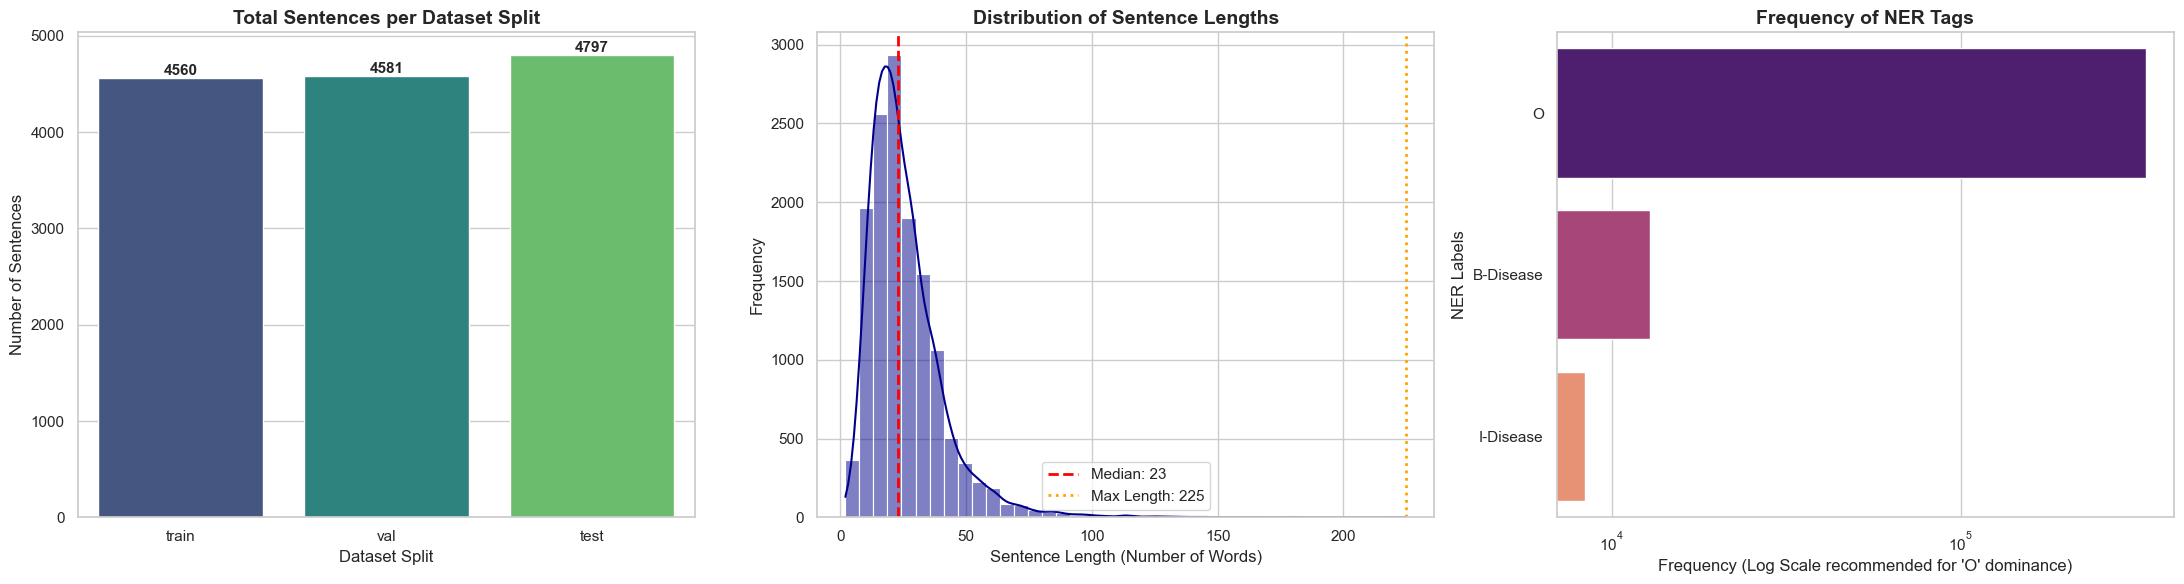

Data Insights Summary Table:
Total Combined Sentences : 13938
Maximum Sentence Length  : 225 words
Median Sentence Length   : 23 words
--------------------------------------------------------------------
NER Tag Frequencies:
  O            : 339,143 occurrences
  B-Disease    : 12,852 occurrences
  I-Disease    : 8,378 occurrences


In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. Load all processed JSON datasets
splits = ["train", "val", "test"]
datasets = {}

for split in splits:
    with open(f"./processed_base_data/{split}.json", "r", encoding="utf-8") as f:
        datasets[split] = json.load(f)

# 2. Extract statistics for plotting
split_counts = {split: len(datasets[split]) for split in splits}

sentence_lengths = []
all_tags = []

for split in splits:
    for sample in datasets[split]:
        # Track sequence lengths (word counts)
        sentence_lengths.append(len(sample["words"]))
        # Track all NER tags (excluding structural symbols if any, but keeping standard tags)
        all_tags.extend(sample["labels"])

# Convert tag list to a frequency distribution dictionary
tag_counts = Counter(all_tags)

# 3. Setup the plotting canvas (3 distinct subplots)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot A: Total Sentence Count per Dataset Split ---
sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
axes[0].set_title("Total Sentences per Dataset Split", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dataset Split", fontsize=12)
axes[0].set_ylabel("Number of Sentences", fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=11, fontweight="bold")

# --- Plot B: Sentence Length Distribution (Sequence Length Analysis) ---
sns.histplot(sentence_lengths, bins=40, kde=True, ax=axes[1], color="darkblue")
axes[1].set_title("Distribution of Sentence Lengths", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sentence Length (Number of Words)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Calculate and overlay median/max sequence stats
median_len = pd.Series(sentence_lengths).median()
max_len = max(sentence_lengths)
axes[1].axvline(median_len, color="red", linestyle="--", linewidth=2, label=f"Median: {int(median_len)}")
axes[1].axvline(max_len, color="orange", linestyle=":", linewidth=2, label=f"Max Length: {max_len}")
axes[1].legend(fontsize=11)

# --- Plot C: NER Label/Tag Distribution Frequency ---
# Convert to DataFrame for easier plotting with Seaborn
tag_df = pd.DataFrame(tag_counts.items(), columns=["Tag", "Frequency"]).sort_values(by="Frequency", ascending=False)
sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")
axes[2].set_title("Frequency of NER Tags", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Frequency (Log Scale recommended for 'O' dominance)", fontsize=12)
axes[2].set_ylabel("NER Labels", fontsize=12)
axes[2].set_xscale("log")  # Using log scale since 'O' tags completely dominate entity tags

# 4. Render and adjust layout
plt.tight_layout()
plt.show()

# 5. Print a quick text summary for confirmation
print("====================================================================")
print("Data Insights Summary Table:")
print("====================================================================")
print(f"Total Combined Sentences : {sum(split_counts.values())}")
print(f"Maximum Sentence Length  : {max_len} words")
print(f"Median Sentence Length   : {int(median_len)} words")
print("--------------------------------------------------------------------")
print("NER Tag Frequencies:")
for tag, count in tag_df.values:
    print(f"  {tag:<12} : {count:,} occurrences")
print("====================================================================")